In [2]:
import tensorflow as tf
print(tf.__version__)

2.17.1


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras import layers

### Defining some constants

In [4]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
data_dir = "/kaggle/input/oversampled-no-background-dataset/oversampled_no_background_dataset"

In [5]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(data_dir, shuffle = True, batch_size = BATCH_SIZE, image_size = (IMAGE_SIZE, IMAGE_SIZE))

Found 6044 files belonging to 4 classes.


In [6]:
import os
class_names = dataset.class_names #leaf diseases
# Get the number of images in each folder
image_counts = {class_name: len(os.listdir(os.path.join(f'{data_dir}', class_name))) for class_name in class_names}
print("Class names and their corresponding integer labels:")
for index, class_name in enumerate(class_names):    
    print(f"{index}: {class_name}")

Class names and their corresponding integer labels:
0: bacterial_blight_resized
1: frogeye_resized
2: healthy_resized
3: potassium_deficiency_resized


In [7]:
class_names = dataset.class_names
class_names

['bacterial_blight_resized',
 'frogeye_resized',
 'healthy_resized',
 'potassium_deficiency_resized']

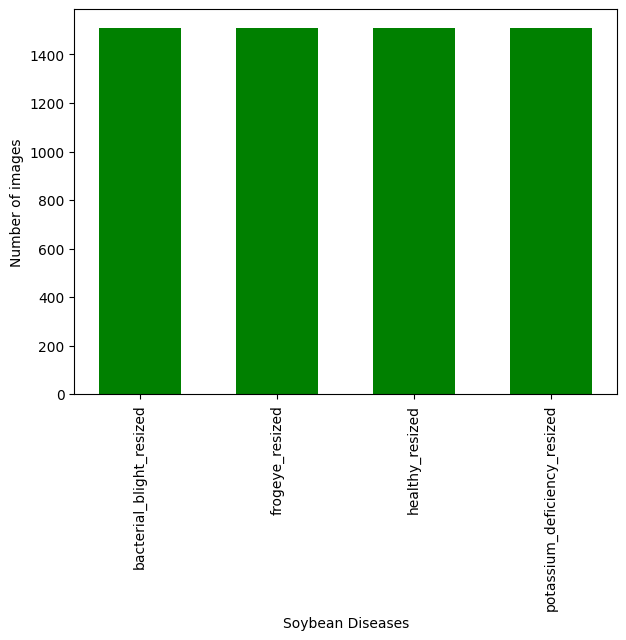

In [33]:
plt.figure(figsize = (7,5))
plt.bar(list(image_counts.keys()), list(image_counts.values()), color = 'green', width = 0.6)
plt.xlabel("Soybean Diseases")
plt.ylabel("Number of images")
plt.xticks(rotation = 90)
plt.savefig("data_distribution.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

## Splitting the dataset

In [9]:
#we dont have train_test_split in tensors like we do in sci-kit learn, so we define our own function
def get_dataset_partitions_tf(ds, train_split = 0.80, valid_split = 0.10, test_split = 0.10, shuffle = True, shuffle_size = 10000):    
    if shuffle:        
        ds = ds.shuffle(shuffle_size) #you can also give a seed    
        ds_size = len(ds)    
        train_size = int(len(ds) * train_split)    
        valid_size = int(len(ds) * valid_split)    
        test_size = int(len(ds) * test_split)    
        train_ds = ds.take(train_size)    
        valid_ds = ds.skip(train_size).take(valid_size)    
        test_ds = ds.skip(train_size + valid_size).take(test_size)    
        return train_ds, valid_ds, test_ds

In [10]:
train_ds, valid_ds, test_ds = get_dataset_partitions_tf(dataset)
len(train_ds), len(valid_ds), len(test_ds)

(151, 18, 18)

In [11]:
train_ds = train_ds.shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
valid_ds = valid_ds.shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [12]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

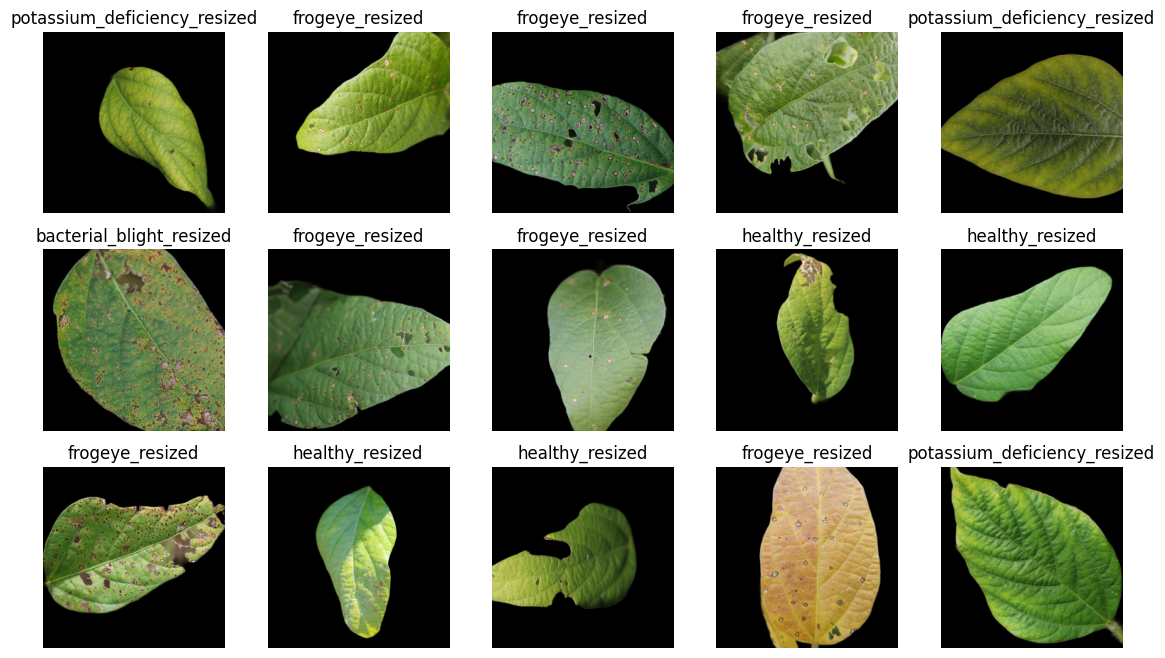

In [13]:
plt.figure(figsize = (14,8))
for batch_of_images, batch_of_labels in dataset.take(1):    
    for i in range(15):        
        ax = plt.subplot(3, 5, i+1)        
        plt.imshow(batch_of_images[i].numpy().astype('uint8')) #we convert the tensor into a numpy array of type 8 bit unsigned int        
        plt.title(class_names[batch_of_labels[i]])        
        plt.axis("off")

## Model Definition and Training

In [14]:
# original training model (keep as is for training)
def create_training_model(IMAGE_SIZE, n_classes):
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ], name="data_augmentation")

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)
    
    # Main architecture
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.35, name='dropout')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='predictions')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name='training_model')
    return model

In [15]:
# Create inference model WITHOUT augmentation for GradCAM
def create_inference_model(trained_model, IMAGE_SIZE, n_classes):
    """
    Creates a new model with the same architecture but without data augmentation.
    This model will be used for inference and GradCAM.
    """
    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    
    # Start directly with rescaling (no augmentation)
    x = layers.Rescaling(1.0 / 255)(inputs)
    
    # Replicate the exact same architecture
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3_1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.35, name='dropout')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='predictions')(x)
    
    inference_model = keras.Model(inputs=inputs, outputs=outputs, name='inference_model')
    
    # Transfer weights from trained model (skip augmentation layers)
    # Find where the actual learnable layers start in the trained model
    weight_mapping = []
    
    # Get layer names that have weights from both models
    trained_layer_names = [layer.name for layer in trained_model.layers if layer.get_weights()]
    inference_layer_names = [layer.name for layer in inference_model.layers if layer.get_weights()]
    
    # Copy weights for matching layers
    for inf_layer in inference_model.layers:
        if inf_layer.get_weights():  # Only layers with weights
            # Find corresponding layer in trained model
            for trained_layer in trained_model.layers:
                if (trained_layer.name == inf_layer.name and 
                    trained_layer.get_weights() and
                    len(trained_layer.get_weights()) == len(inf_layer.get_weights())):
                    inf_layer.set_weights(trained_layer.get_weights())
                    break
    
    return inference_model

In [16]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath= "best_model.weights.h5",
    save_weights_only=True,  # Only save the weights, not the entire model
    monitor='val_loss',  # Monitor validation accuracy (or another metric like 'val_loss')
    mode='min',              
    save_best_only=True      # Only save the model when the monitored metric improves
)

In [17]:
#1. Train your model as usual
training_model = create_training_model(IMAGE_SIZE=256, n_classes=4)
training_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
training_model.summary()

Model: "training_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_1 (Conv2D)                     │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_2 (Conv2D)                     │ (None, 256, 256, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_1 (Conv2D)                     │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3_1 (Conv2D)                     │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 131072)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 128)                 │      16,777,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,880,356 (64.39 MB)

 Trainable params: 16,880,356 (64.39 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
training_model.fit(train_ds, validation_data=valid_ds, epochs=30, callbacks = [model_checkpoint_callback])

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 66s 201ms/step - accuracy: 0.3974 - loss: 1.3086 - val_accuracy: 0.6736 - val_loss: 0.8029
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 50s 210ms/step - accuracy: 0.6632 - loss: 0.8127 - val_accuracy: 0.8142 - val_loss: 0.4540
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.7684 - loss: 0.5783 - val_accuracy: 0.8090 - val_loss: 0.4572
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 200ms/step - accuracy: 0.8255 - loss: 0.4727 - val_accuracy: 0.8958 - val_loss: 0.2635
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.8783 - loss: 0.3416 - val_accuracy: 0.8750 - val_loss: 0.3235
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.8975 - loss: 0.2868 - val_accuracy: 0.8733 - val_loss: 0.3461
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 195ms/step - accuracy: 0.9133 - loss: 0.2306 - val_accuracy: 0.8941 - val_loss: 0.2961
Epoch 8/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.9263 - loss: 0

In [23]:
# Step 1: Rebuild training model architecture
training_model_for_weights = create_training_model(IMAGE_SIZE, n_classes)

# Step 2: Load best saved weights
training_model_for_weights.load_weights("best_model.weights.h5")

# Step 3: Create inference model
inference_model = create_inference_model(training_model_for_weights, IMAGE_SIZE, 4)

In [20]:
# 2. Create inference model for GradCAM
inference_model = create_inference_model(training_model, IMAGE_SIZE=256, n_classes=4)

# 3. Use inference model for predictions and GradCAM
# predictions = inference_model.predict(your_image)
# heatmap = make_gradcam_heatmap(your_image, inference_model, 'conv3_1')

In [25]:
inference_model.compile(
    optimizer="adam",  # doesn't matter much for evaluation
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
loss, accuracy = inference_model.evaluate(test_ds)
print(f"Testing Loss: {loss}, Testing Accuracy: {accuracy}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9654 - loss: 0.0926
Testing Loss: 0.09067567437887192, Testing Accuracy: 0.9652777910232544


In [28]:
training_model_for_weights.save("best_weights_training_model.keras")
training_model.save("training_model.keras")
inference_model.save("inference_model.keras")

In [30]:
import numpy as np
from IPython.display import clear_output  # For clearing output in Jupyter Notebook

y_true = []  # Initialize as lists
y_pred = []  

# Iterate through the test dataset
for x_batch, y_batch in test_ds:    
    y_true.extend(y_batch.numpy().tolist())  # Convert to list and extend
    predictions = inference_model.predict(x_batch)    
    y_pred.extend(tf.argmax(predictions, axis=1).numpy().tolist())  # Convert to list and extend

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


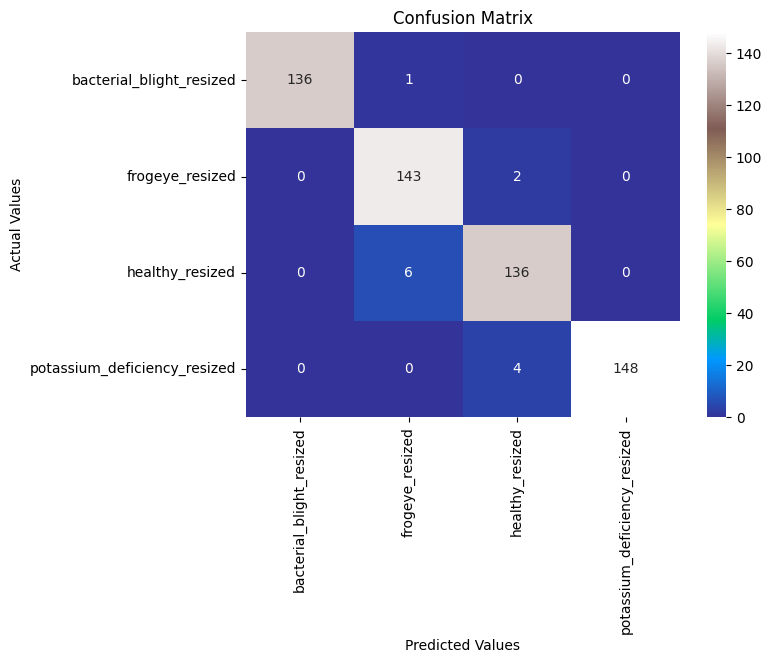

In [31]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='terrain' , xticklabels = class_names, yticklabels =  class_names) # or use cmap = terrain
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
# Calculate Precision, Recall, and F1-Score
precision = precision_score(y_true, y_pred, average='weighted')  # Use 'macro' or 'micro' if needed
recall = recall_score(y_true, y_pred, average='weighted')  
f1 = f1_score(y_true, y_pred, average='weighted')  

# Print results
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print("\nClassification Report:")
clf_report = classification_report(y_true, y_pred)
print(clf_report)

Precision: 0.9778
Recall: 0.9774
F1-Score: 0.9775

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       137
           1       0.95      0.99      0.97       145
           2       0.96      0.96      0.96       142
           3       1.00      0.97      0.99       152

    accuracy                           0.98       576
   macro avg       0.98      0.98      0.98       576
weighted avg       0.98      0.98      0.98       576

